In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor  # Bagging
from xgboost import XGBRegressor  # Boosting
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

In [42]:
# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("SuperKart.csv")
Xtrain = pd.read_csv("Xtrain.csv")
Xtest  = pd.read_csv("Xtest.csv")
ytrain = pd.read_csv("ytrain.csv")
ytest  = pd.read_csv("ytest.csv")



In [43]:
#---------------------------------------------------------
#clean column names and ensure 100% compatibility
#---------------------------------------------------------
df.columns = df.columns.str.strip()
# XGBoost rejects '[', ']', '<' in feature names — clean them up
df.columns = (df.columns
              .str.replace(r"\s*\[.*?\]", "", regex=True)
              .str.strip())
#------------------------------------------------------------------
print("\nMissing values:\n", df.isna().sum().sum(), "total")


Missing values:
 0 total


In [44]:
df.head(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [45]:
print("Shape:", df.shape)

Shape: (8763, 12)


In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
df.describe()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


In [48]:
df = df.drop(columns=['Product_Id'], errors='ignore')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Weight             8763 non-null   float64
 1   Product_Sugar_Content      8763 non-null   object 
 2   Product_Allocated_Area     8763 non-null   float64
 3   Product_Type               8763 non-null   object 
 4   Product_MRP                8763 non-null   float64
 5   Store_Id                   8763 non-null   object 
 6   Store_Establishment_Year   8763 non-null   int64  
 7   Store_Size                 8763 non-null   object 
 8   Store_Location_City_Type   8763 non-null   object 
 9   Store_Type                 8763 non-null   object 
 10  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 753.2+ KB


In [50]:
df.head(5)

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [51]:
df.dtypes

,0
Product_Weight,float64
Product_Sugar_Content,object
Product_Allocated_Area,float64
Product_Type,object
Product_MRP,float64
Store_Id,object
Store_Establishment_Year,int64
Store_Size,object
Store_Location_City_Type,object
Store_Type,object


In [54]:
df['Product_Sugar_Content'] = df['Product_Sugar_Content'].replace({'reg': 'Regular'})
df['Product_Sugar_Content'] = df['Product_Sugar_Content'].map(
    {'No Sugar': 0, 'Low Sugar': 1, 'Regular': 2}
)

le_store_size = LabelEncoder()
df['Store_Size'] = le_store_size.fit_transform(df['Store_Size'].astype(str))

le_product = LabelEncoder()
df['Product_Type'] = le_product.fit_transform(df['Product_Type'])

le_store_type = LabelEncoder()
df['Store_Type'] = le_store_type.fit_transform(df['Store_Type'])
le_city_type = LabelEncoder()
df['Store_Location_City_Type'] = le_city_type.fit_transform(df['Store_Location_City_Type'])
le_store_id = LabelEncoder()
df['Store_Id'] = le_store_id.fit_transform(df['Store_Id'])

In [55]:
df.head(5)

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,12.66,NaN,0.027,5,117.08,3,2009,1,1,3,2842.40
1,16.54,NaN,0.144,4,171.43,2,1999,1,0,0,4830.02
2,14.28,NaN,0.031,3,162.08,0,1987,0,1,2,4130.16
3,12.10,NaN,0.112,0,186.31,0,1987,0,1,2,4132.18
4,9.57,NaN,0.010,8,123.67,1,1998,2,2,1,2279.36


count    8763.000000
mean     3464.003640
std      1065.630494
min        33.000000
25%      2761.715000
50%      3452.340000
75%      4145.165000
max      8000.000000
Name: Product_Store_Sales_Total, dtype: float64


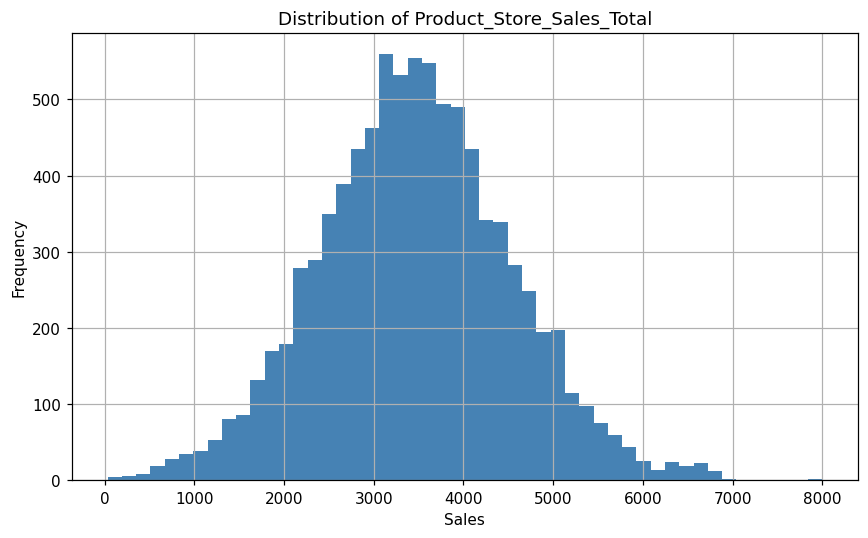

In [56]:
# ------------------------------------------------------------
# 2. EDA — target distribution (regression)
# ------------------------------------------------------------

print(df["Product_Store_Sales_Total"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
df["Product_Store_Sales_Total"].hist(bins=50, ax=ax, color="steelblue")
ax.set_title("Distribution of Product_Store_Sales_Total")
ax.set_xlabel("Sales")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [57]:
# ------------------------------------------------------------
# 3. FEATURE ENGINEERING
# ------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder

Xtrain = pd.read_csv("Xtrain.csv")
Xtest  = pd.read_csv("Xtest.csv")
ytrain = pd.read_csv("ytrain.csv")
ytest  = pd.read_csv("ytest.csv")

le_dict = {}

# ------------------------------------------------------------
# fix dirty label before encoding
# ------------------------------------------------------------
for df_ in [Xtrain, Xtest]:
    df_['Product_Sugar_Content'] = df_['Product_Sugar_Content'].replace({'reg': 'Regular'})

# ------------------------------------------------------------
# Domain-informed engineered features
# ------------------------------------------------------------
for df_ in [Xtrain, Xtest]:
    df_['Store_Age'] = 2024 - df_['Store_Establishment_Year']
    df_['Price_per_Weight'] = df_['Product_MRP'] / df_['Product_Weight']
    df_['MRP_per_Area'] = df_['Product_MRP'] * df_['Product_Allocated_Area']

# ------------------------------------------------------------
# Encode ordinal categoricals - mapping )
# ------------------------------------------------------------
sugar_map = {'No Sugar': 0, 'Low Sugar': 1, 'Regular': 2}
size_map  = {'Small': 0, 'Medium': 1, 'High': 2}
tier_map  = {'Tier 3': 0, 'Tier 2': 1, 'Tier 1': 2}

for df_ in [Xtrain, Xtest]:
    df_['Product_Sugar_Content'] = df_['Product_Sugar_Content'].map(sugar_map)
    df_['Store_Size'] = df_['Store_Size'].map(size_map)
    df_['Store_Location_City_Type'] = df_['Store_Location_City_Type'].map(tier_map)

# ------------------------------------------------------------
# Encode nominal categoricals - LabelEncoder, Fit on the training set only)
# ------------------------------------------------------------
cat_cols = ['Product_Type', 'Store_Type']

for col in cat_cols:
    le = LabelEncoder()
    Xtrain[col] = le.fit_transform(Xtrain[col])
    Xtest[col] = le.transform(Xtest[col])
    le_dict[col] = le

# ------------------------------------------------------------
# Features & Target
# ------------------------------------------------------------
features = [
    "Product_Weight", "Product_Sugar_Content", "Product_Allocated_Area",
    "Product_Type", "Product_MRP", "Store_Establishment_Year",
    "Store_Size", "Store_Location_City_Type", "Store_Type",
    "Store_Age", "Price_per_Weight", "MRP_per_Area"
]
target = "Product_Store_Sales_Total"

X_train = Xtrain[features]
X_test  = Xtest[features]
y_train = ytrain[target]
y_test  = ytest[target]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (7010, 12) | X_test: (1753, 12)
y_train: (7010,) | y_test: (1753,)


In [64]:
df.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,12.66,NaN,0.027,5,117.08,3,2009,1,1,3,2842.40
1,16.54,NaN,0.144,4,171.43,2,1999,1,0,0,4830.02
2,14.28,NaN,0.031,3,162.08,0,1987,0,1,2,4130.16
3,12.10,NaN,0.112,0,186.31,0,1987,0,1,2,4132.18
4,9.57,NaN,0.010,8,123.67,1,1998,2,2,1,2279.36


In [65]:
# ------------------------------------------------------------
# 5. MODEL — XGBoost Regressor
# ------------------------------------------------------------
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = xgb.XGBRegressor(
    n_estimators=300,       # Number of trees
    max_depth=5,            # Prevents overfitting
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  121.53
RMSE: 288.38
R²:   0.9271


In [66]:
# ------------------------------------------------------------
# 6. CHECK OVERFITTING -training set vs the test set.
# ------------------------------------------------------------
y_pred_train = model.predict(X_train)
print("Train R²:", r2_score(y_train, y_pred_train))

Train R²: 0.9592304048295491


In [67]:
# ------------------------------------------------------------
# 6. EVALUATION — forecast accuracy(Regression Metrics)
# ------------------------------------------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== Model Performance ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")

# ------------------------------------------------------------
# Error Rate
# ------------------------------------------------------------
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"\nMAPE: {mape:.2f}%  (متوسط نسبة الخطأ)")


=== Model Performance ===
MAE:  121.53
RMSE: 288.38
R²:   0.9271

MAPE: 4.40%  (متوسط نسبة الخطأ)



Feature importance:
 Store_Location_City_Type    0.342999
Store_Size                  0.325583
Store_Establishment_Year    0.153449
Product_MRP                 0.140447
Product_Weight              0.026202
Price_per_Weight            0.002358
Product_Allocated_Area      0.002029
Store_Type                  0.001909
MRP_per_Area                0.001861
Product_Type                0.001757
Product_Sugar_Content       0.001405
Store_Age                   0.000000
dtype: float32


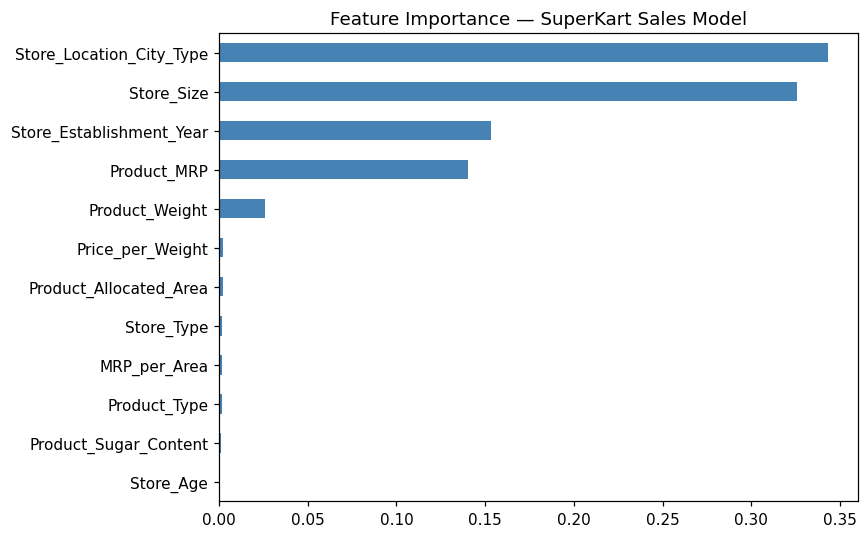

In [68]:
# ------------------------------------------------------------
# 7. FEATURE IMPORTANCE
# ------------------------------------------------------------
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature importance:\n", importance)

# رسم بياني
fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Feature Importance — SuperKart Sales Model")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


          total_sales    avg_sales  num_products store_size city_type  \
Store_Id                                                                
OUT004    15427583.43  3299.312111          4676     Medium    Tier 2   
OUT003     6673457.57  4946.966323          1349     Medium    Tier 1   
OUT001     6223113.18  3923.778802          1586       High    Tier 2   
OUT002     2030909.72  1762.942465          1152      Small    Tier 3   

                  store_type  establishment_year  
Store_Id                                          
OUT004     Supermarket Type2                2009  
OUT003    Departmental Store                1999  
OUT001     Supermarket Type1                1987  
OUT002             Food Mart                1998  


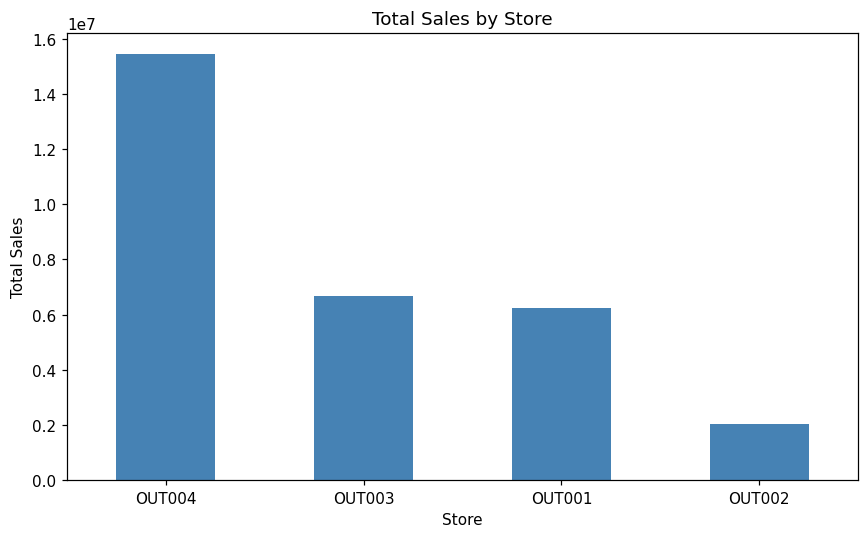


متوسط المبيعات حسب حجم الفرع:
Store_Size
High      3923.778802
Medium    3668.222573
Small     1762.942465
Name: Product_Store_Sales_Total, dtype: float64

متوسط المبيعات حسب نوع المدينة:
Store_Location_City_Type
Tier 1    4946.966323
Tier 2    3457.473109
Tier 3    1762.942465
Name: Product_Store_Sales_Total, dtype: float64


In [69]:
# ------------------------------------------------------------
# STORE PERFORMANCE ANALYSIS
# ------------------------------------------------------------


df_full = pd.read_csv("SuperKart.csv")

store_performance = df_full.groupby("Store_Id").agg(
    total_sales=("Product_Store_Sales_Total", "sum"),
    avg_sales=("Product_Store_Sales_Total", "mean"),
    num_products=("Product_Store_Sales_Total", "count"),
    store_size=("Store_Size", "first"),
    city_type=("Store_Location_City_Type", "first"),
    store_type=("Store_Type", "first"),
    establishment_year=("Store_Establishment_Year", "first")
).sort_values("total_sales", ascending=False)

print(store_performance)

# ------------------------------------------------------------
# Total Sales by Branch
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
store_performance["total_sales"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Total Sales by Store")
ax.set_xlabel("Store")
ax.set_ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Average sales by branch size and city type
# ------------------------------------------------------------
print("\nمتوسط المبيعات حسب حجم الفرع:")
print(df_full.groupby("Store_Size")["Product_Store_Sales_Total"].mean().sort_values(ascending=False))

print("\nمتوسط المبيعات حسب نوع المدينة:")
print(df_full.groupby("Store_Location_City_Type")["Product_Store_Sales_Total"].mean().sort_values(ascending=False))

In [70]:
best_store = store_performance.index[0]
best_sales = store_performance.iloc[0]['total_sales']
print(f"\n🏆 The best-selling store: {best_store} total of {best_sales:,.2f} Eg")
print(f"   ({store_performance.iloc[0]['store_size']} store, {store_performance.iloc[0]['city_type']}, established {int(store_performance.iloc[0]['establishment_year'])})")


🏆 The best-selling store: OUT004 total of 15,427,583.43 Eg
   (Medium store, Tier 2, established 2009)



Saved: model_results.png


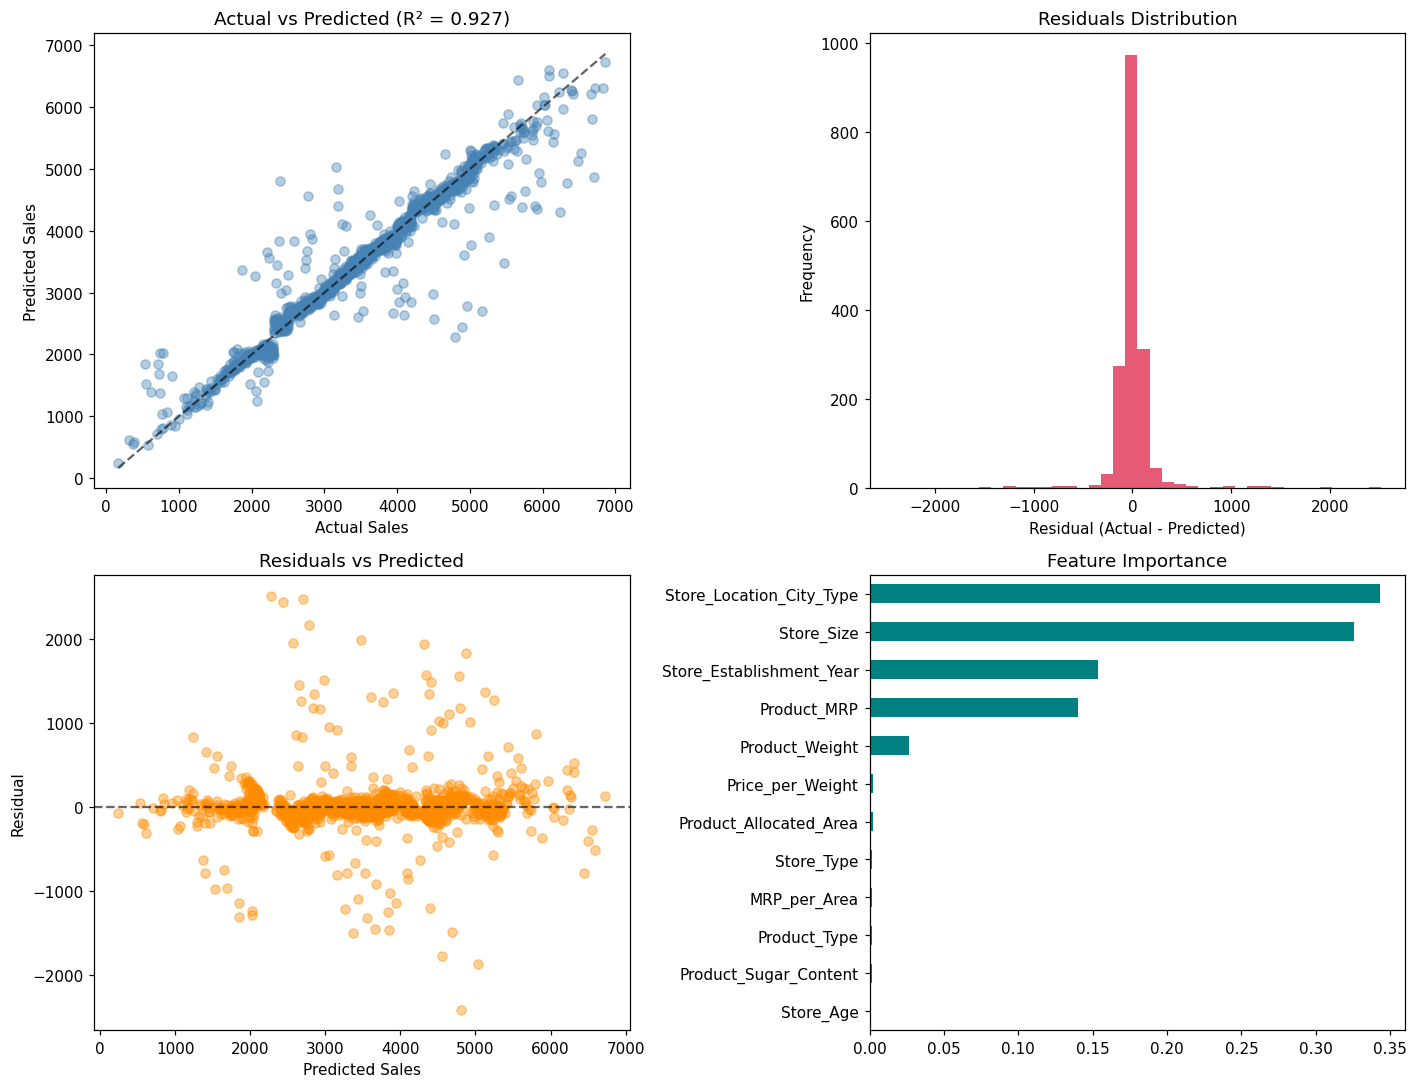

In [71]:
# ------------------------------------------------------------
# 9. VISUALIZATIONS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Actual vs Predicted scatter
axes[0, 0].scatter(y_test, y_pred, alpha=0.4, color="steelblue")
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", alpha=0.6)
axes[0, 0].set_xlabel("Actual Sales")
axes[0, 0].set_ylabel("Predicted Sales")
axes[0, 0].set_title(f"Actual vs Predicted (R² = {r2:.3f})")

# Residuals distribution
residuals = y_test.values - y_pred
axes[0, 1].hist(residuals, bins=40, color="crimson", alpha=0.7)
axes[0, 1].set_xlabel("Residual (Actual - Predicted)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Residuals Distribution")

# Residuals vs Predicted (يوضح لو فيه pattern في الأخطاء)
axes[1, 0].scatter(y_pred, residuals, alpha=0.4, color="darkorange")
axes[1, 0].axhline(0, color="k", linestyle="--", alpha=0.6)
axes[1, 0].set_xlabel("Predicted Sales")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("Residuals vs Predicted")

# Feature importance
importance.plot(kind="barh", ax=axes[1, 1], color="teal")
axes[1, 1].invert_yaxis()
axes[1, 1].set_title("Feature Importance")

plt.tight_layout()
plt.savefig("model_results.png", dpi=150)
print("\nSaved: model_results.png")

In [72]:
# ------------------------------------------------------------
# 10. FINAL SUMMARY
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print(f"""
Dataset: SuperKart — {len(X_train) + len(X_test)} records (Product_Weight, Product_MRP, Store_Type, etc.)
Model: XGBoost Regressor (n_estimators=300, max_depth=5, learning_rate=0.05)

Performance:
  MAE:  {mae:.2f}
  RMSE: {rmse:.2f}
  R²:   {r2:.4f}
  MAPE: {mape:.2f}%

Top predictive signals: {', '.join(importance.head(4).index.tolist())}

Business framing: Store location and store size are the strongest drivers of
sales — more influential than product-level attributes like price or type.
This suggests expansion strategy should prioritize site selection (city tier,
store size) over product mix diversification to maximize sales per outlet.
""")


PROJECT SUMMARY

Dataset: SuperKart — 8763 records (Product_Weight, Product_MRP, Store_Type, etc.)
Model: XGBoost Regressor (n_estimators=300, max_depth=5, learning_rate=0.05)

Performance:
  MAE:  121.53
  RMSE: 288.38
  R²:   0.9271
  MAPE: 4.40%

Top predictive signals: Store_Location_City_Type, Store_Size, Store_Establishment_Year, Product_MRP

Business framing: Store location and store size are the strongest drivers of
sales — more influential than product-level attributes like price or type.
This suggests expansion strategy should prioritize site selection (city tier,
store size) over product mix diversification to maximize sales per outlet.



In [73]:
# Install Gradio
!pip install gradio


## PART 3 — Gradio UI


In [81]:
# ================================================
# GRADIO UI — SuperKart Sales Predictor (XGBoost Regressor)
# ================================================
import gradio as gr
import pandas as pd

SUGAR_MAP = {"No Sugar": 0, "Low Sugar": 1, "Regular": 2}
SIZE_MAP  = {"Small": 0, "Medium": 1, "High": 2}
TIER_MAP  = {"Tier 3": 0, "Tier 2": 1, "Tier 1": 2}

PRODUCT_TYPE_ENCODER = le_dict["Product_Type"]
STORE_TYPE_ENCODER = le_dict["Store_Type"]


def predict_sales(product_weight, sugar_content, allocated_area, product_type,
                   product_mrp, establishment_year, store_size, city_type, store_type):
    try:
        sugar_encoded = SUGAR_MAP[sugar_content]
        size_encoded = SIZE_MAP[store_size]
        tier_encoded = TIER_MAP[city_type]
        type_encoded = PRODUCT_TYPE_ENCODER.transform([product_type])[0]
        store_type_encoded = STORE_TYPE_ENCODER.transform([store_type])[0]

        store_age = 2024 - establishment_year
        price_per_weight = product_mrp / product_weight
        mrp_per_area = product_mrp * allocated_area

        row = pd.DataFrame([{
            "Product_Weight": product_weight,
            "Product_Sugar_Content": sugar_encoded,
            "Product_Allocated_Area": allocated_area,
            "Product_Type": type_encoded,
            "Product_MRP": product_mrp,
            "Store_Establishment_Year": establishment_year,
            "Store_Size": size_encoded,
            "Store_Location_City_Type": tier_encoded,
            "Store_Type": store_type_encoded,
            "Store_Age": store_age,
            "Price_per_Weight": price_per_weight,
            "MRP_per_Area": mrp_per_area
        }])[features]

        prediction = model.predict(row)[0]

        return f"""
        <div style="text-align:center; padding:20px; background:linear-gradient(135deg,#667eea,#764ba2);
                    border-radius:16px; color:white;">
            <p style="font-size:16px; margin:0; opacity:0.85;">Predicted Sales</p>
            <p style="font-size:42px; font-weight:800; margin:8px 0;">{prediction:,.2f}</p>
            <p style="font-size:14px; margin:0; opacity:0.7;">EGP</p>
        </div>
        """
    except Exception as e:
        return f"""<div style="padding:20px; background:#fee; border-radius:12px; color:#c00;">
        ❌ خطأ: {str(e)}</div>"""


CUSTOM_CSS = """
.gradio-container {font-family: 'Segoe UI', sans-serif; max-width: 900px !important; margin: auto;}
#title {text-align:center; font-size:28px; font-weight:800; margin-bottom:4px;}
#subtitle {text-align:center; color:#666; margin-bottom:20px;}
"""

with gr.Blocks(css=CUSTOM_CSS, theme=gr.themes.Soft(primary_hue="indigo")) as demo:
    gr.Markdown("# 🛒 SuperKart Sales Predictor", elem_id="title")
    gr.Markdown("XGBoost Regressor — توقّع مبيعات المنتج في الفرع بناءً على خصائصه وخصائص الفرع", elem_id="subtitle")

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📦 بيانات المنتج")
            product_weight = gr.Slider(4, 22, value=12.5, step=0.1, label="Product Weight (kg)")
            sugar_content = gr.Radio(["No Sugar", "Low Sugar", "Regular"], value="No Sugar", label="Sugar Content")
            allocated_area = gr.Slider(0.0, 0.3, value=0.05, step=0.001, label="Allocated Area")
            product_type = gr.Dropdown(PRODUCT_TYPE_ENCODER.classes_.tolist(), label="Product Type")
            product_mrp = gr.Slider(30, 300, value=150.0, step=0.5, label="Product MRP")

        with gr.Column(scale=1):
            gr.Markdown("### 🏬 بيانات الفرع")
            establishment_year = gr.Dropdown([1987, 1998, 1999, 2009], value=2009, label="Store Establishment Year")
            store_size = gr.Radio(["Small", "Medium", "High"], value="Medium", label="Store Size")
            city_type = gr.Radio(["Tier 1", "Tier 2", "Tier 3"], value="Tier 2", label="Store Location City Type")
            store_type = gr.Dropdown(STORE_TYPE_ENCODER.classes_.tolist(), label="Store Type")

    predict_btn = gr.Button("🔮 Sales forecasting", variant="primary", size="lg")
    output = gr.HTML()

    predict_btn.click(
        fn=predict_sales,
        inputs=[product_weight, sugar_content, allocated_area, product_type,
                product_mrp, establishment_year, store_size, city_type, store_type],
        outputs=output
    )

demo.launch()

/tmp/ipykernel_4743/2475295463.py:64: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=CUSTOM_CSS, theme=gr.themes.Soft(primary_hue="indigo")) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a534c17b1e09396937.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
